# Santiago Marin Yepes

In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

In [19]:
!pip install pylatexenc

In [31]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer  # Se ha cambiado de qiskit import Aer a qiskit_aer import Aer. IBM corretion
from qiskit.visualization import plot_histogram

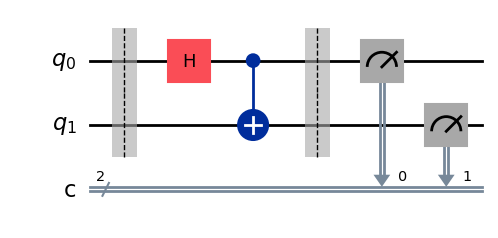

In [42]:
q_bell = QuantumCircuit(2,2)
q_bell.barrier()
q_bell.h(0)
q_bell.cx(0,1)
q_bell.barrier()
q_bell.measure([0,1],[0,1]) # Measure qubits 0 and 1 into classical bits 0 and 1 (second[0,1] is the classical register)

q_bell.draw(output='mpl',plot_barriers=True)

{'00': 524, '11': 476}


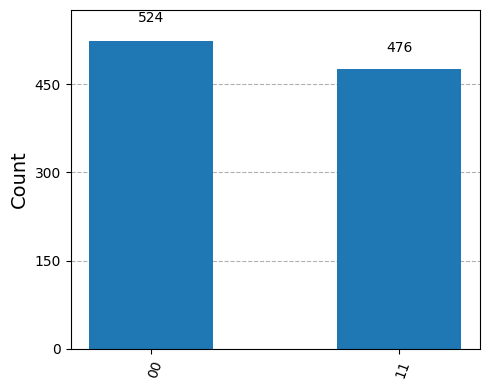

In [43]:
# 2. Set up your backend
backend = Aer.get_backend('qasm_simulator') # locally

# 3. Transpile the circuit for your specific backend. transport compilation
compiled_circuit = transpile(q_bell, backend)

# 4. Run the circuit using the backend's run method.
job = backend.run(compiled_circuit, shots=1000) # shots: number of times to run the circuit

result_sim = job.result()

print(result_sim.get_counts(q_bell))
plot_histogram(result_sim.get_counts(q_bell),figsize=(5,4))

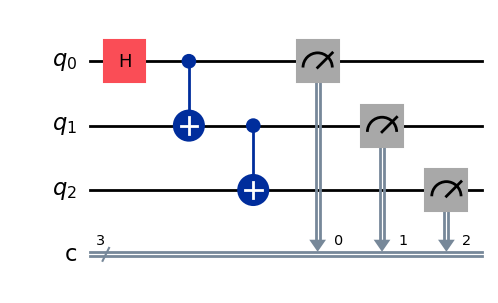

In [33]:
qc1 = QuantumCircuit(3, 3)

qc1.h(0)
qc1.cx(0, 1)
qc1.cx(1, 2)

qc1.measure(0, 0)
qc1.measure(1, 1)
qc1.measure(2, 2)

qc1.draw("mpl")

{'111': 511, '000': 489}


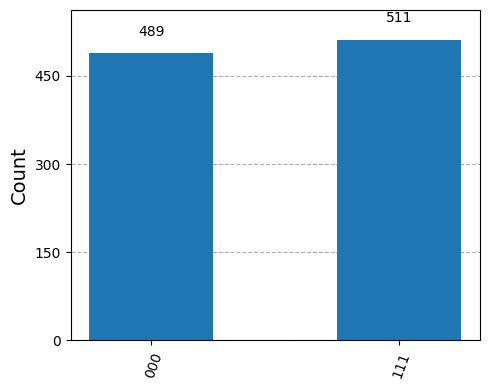

In [47]:
# 2. Set up your backend
backend = Aer.get_backend('qasm_simulator') # locally

# 3. Transpile the circuit for your specific backend. transport compilation
compiled_circuit = transpile(qc1, backend)

# 4. Run the circuit using the backend's run method.
job = backend.run(compiled_circuit, shots=1000) # shots: number of times to run the circuit

result_sim = job.result()

print(result_sim.get_counts(qc1))
plot_histogram(result_sim.get_counts(qc1),figsize=(5,4))

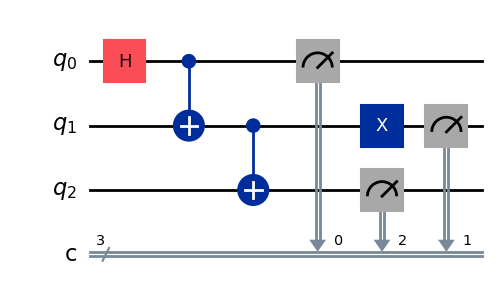

In [34]:
qc2 = QuantumCircuit(3, 3)

qc2.h(0)
qc2.cx(0, 1)
qc2.cx(1, 2)
qc2.x(1)
qc2.measure(0, 0)
qc2.measure(1, 1)
qc2.measure(2, 2)

qc2.draw("mpl")

{'101': 516, '010': 484}


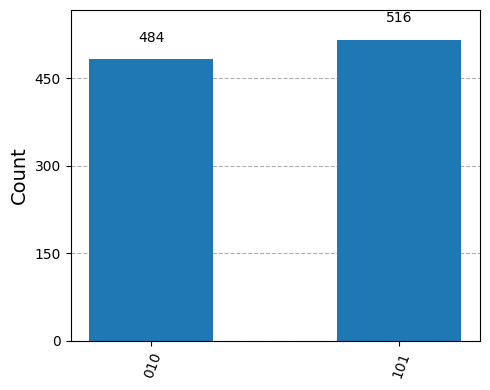

In [40]:
# 2. Set up your backend
backend = Aer.get_backend('qasm_simulator') # locally

# 3. Transpile the circuit for your specific backend. transport compilation
compiled_circuit = transpile(qc2, backend)

# 4. Run the circuit using the backend's run method.
job = backend.run(compiled_circuit, shots=1000) # shots: number of times to run the circuit

result_sim = job.result()

print(result_sim.get_counts(qc2))
plot_histogram(result_sim.get_counts(qc2),figsize=(5,4))

**Análisis**

Observé que, al añadir un tercer qubit, el estado tipo Bell conserva una estructura similar al caso de dos qubits. En lugar de obtener una superposición entre $|00\rangle$ y $|11\rangle$, se obtiene una superposición entre $|000\rangle$ y $|111\rangle$. Esto corresponde a un estado entrelazado de tres qubits, conocido como estado GHZ:

$$
|\psi\rangle =
\frac{1}{\sqrt{2}}
\left(
|000\rangle + |111\rangle
\right).
$$

Al realizar las mediciones, las probabilidades se distribuyeron de manera aproximadamente equitativa entre los estados $000$ y $111$, tal como se esperaba teóricamente.

En el último caso, al aplicar una compuerta NOT al qubit $1$, los estados presentes en la superposición cambiaron. La compuerta NOT invierte el valor del qubit sobre el que actúa, por lo que la superposición pasó de estar formada por los estados $000$ y $111$ a estar formada por los estados $010$ y $101$:

$$
\frac{1}{\sqrt{2}}
\left(
|000\rangle + |111\rangle
\right)
\longrightarrow
\frac{1}{\sqrt{2}}
\left(
|010\rangle + |101\rangle
\right).
$$

Sin embargo, aunque cambiaron los estados medidos, las probabilidades se mantuvieron aproximadamente iguales, repartiéndose cerca del $50\%$ para cada resultado. Esto muestra que la compuerta NOT modifica los estados de la base, pero no cambia la distribución de probabilidades de la superposición.

Nota: 3.5 falto el primer punto... muy bien por acercarse a estos temas. 